# Fourier Neural Operators for Navier-Stokes Vorticity

This notebook builds a small **Fourier Neural Operator (FNO)** for a pared-down version of the Navier-Stokes example from Li et al., *Fourier Neural Operator for Parametric Partial Differential Equations* (arXiv:2010.08895).

The paper studies the forced 2D incompressible Navier-Stokes equations in vorticity form on the unit torus:

$$
\partial_t \omega + u \cdot \nabla \omega = \nu \Delta \omega + f, \qquad \nabla \cdot u = 0,
$$

where $\omega = \nabla \times u$ is vorticity. The original experiments use large simulation datasets and compare several neural operator variants. Here we keep the same physical example but make three classroom simplifications:

- generate a small dataset inside the notebook,
- learn the map $\omega_0(x,y) \mapsto \omega_T(x,y)$ instead of a long rollout,
- train a compact 2D FNO on a coarse periodic grid.

The goal is not state-of-the-art accuracy. The goal is to see why a Fourier layer is a natural building block for a PDE defined on a periodic spatial domain.


In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

rng = np.random.default_rng(4)
torch.manual_seed(4)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = False
plt.rcParams['image.cmap'] = 'turbo'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


## 1. A small Navier-Stokes data generator

We solve the vorticity equation on $[0,1)^2$ with periodic boundaries. The forcing follows the common FNO benchmark setup,

$$
f(x,y) = 0.1\left[\sin(2\pi(x+y)) + \cos(2\pi(x+y))\right].
$$

For a vorticity field $\omega$, the streamfunction $\psi$ satisfies

$$
\omega = -\Delta \psi,
$$

and the incompressible velocity is

$$
u = (\partial_y \psi, -\partial_x \psi).
$$

A few numerical details are worth unpacking before looking at the code.

- We evolve **vorticity**, a scalar field that measures local rotation, rather than the two velocity components directly.
- The streamfunction $\psi$ is a convenient way to recover a divergence-free velocity field. Solving $\omega = -\Delta \psi$ gives $\psi$, and then $u = (\partial_y \psi, -\partial_x \psi)$ automatically satisfies $\nabla \cdot u = 0$.
- On a periodic grid, Fourier modes are the natural basis. Differentiation becomes multiplication by $ik$, and the Poisson solve becomes division by the squared wavenumber $|k|^2$ for every nonzero mode.
- The nonlinear advection term $u \cdot \nabla \omega$ is computed in physical space after taking spectral derivatives. This is called a **pseudospectral** method.
- We use a semi-implicit Euler step: advection and forcing are explicit, while diffusion is implicit. That keeps the solver simple while avoiding the most restrictive stability limit from the viscous term.

This is not meant to be a production CFD solver. It is a compact generator for smooth, periodic training pairs that have the same structure as the FNO Navier-Stokes benchmark.


In [13]:
def periodic_grid(n):
    """Return a periodic grid on [0, 1)^2."""
    x = np.linspace(0.0, 1.0, n, endpoint=False)
    y = np.linspace(0.0, 1.0, n, endpoint=False)
    return np.meshgrid(x, y, indexing='ij')


def wavenumbers(n):
    """Angular Fourier wavenumbers for a unit periodic domain."""
    k = 2 * np.pi * np.fft.fftfreq(n, d=1.0 / n)
    return np.meshgrid(k, k, indexing='ij')


def forcing_field(n):
    x, y = periodic_grid(n)
    return 0.1 * (np.sin(2 * np.pi * (x + y)) + np.cos(2 * np.pi * (x + y)))


def sample_initial_vorticity(n, rng, alpha=7.0, power=2.5):
    """Draw a smooth random vorticity field with stronger low-frequency energy."""
    noise = rng.normal(size=(n, n))
    noise_hat = np.fft.fft2(noise)
    kx, ky = wavenumbers(n)
    k2 = kx**2 + ky**2

    # Smooth spectral filter, similar in spirit to a Gaussian random field prior.
    filt = (alpha**2 / (k2 + alpha**2)) ** (power / 2)
    filt[0, 0] = 0.0
    w = np.fft.ifft2(noise_hat * filt).real
    w = (w - w.mean()) / (w.std() + 1e-6)
    return w.astype(np.float32)


def navier_stokes_step(w, f, nu, dt, kx, ky, k2):
    """One semi-implicit pseudospectral step for 2D vorticity."""
    w_hat = np.fft.fft2(w)

    psi_hat = np.zeros_like(w_hat)
    mask = k2 > 0
    psi_hat[mask] = w_hat[mask] / k2[mask]

    u = np.fft.ifft2(1j * ky * psi_hat).real
    v = np.fft.ifft2(-1j * kx * psi_hat).real
    w_x = np.fft.ifft2(1j * kx * w_hat).real
    w_y = np.fft.ifft2(1j * ky * w_hat).real

    adv = u * w_x + v * w_y
    rhs_hat = np.fft.fft2(-adv + f)
    w_hat_next = (w_hat + dt * rhs_hat) / (1.0 + dt * nu * k2)
    return np.fft.ifft2(w_hat_next).real.astype(np.float32)


def solve_navier_stokes(w0, nu=1e-3, dt=0.01, n_steps=80):
    """Return vorticity after n_steps from initial condition w0."""
    n = w0.shape[0]
    kx, ky = wavenumbers(n)
    k2 = kx**2 + ky**2
    f = forcing_field(n)
    w = w0.astype(np.float32).copy()
    for _ in range(n_steps):
        w = navier_stokes_step(w, f, nu, dt, kx, ky, k2)
    return w


The next cell generates one trajectory so we can check the numerical setup before building a training set.


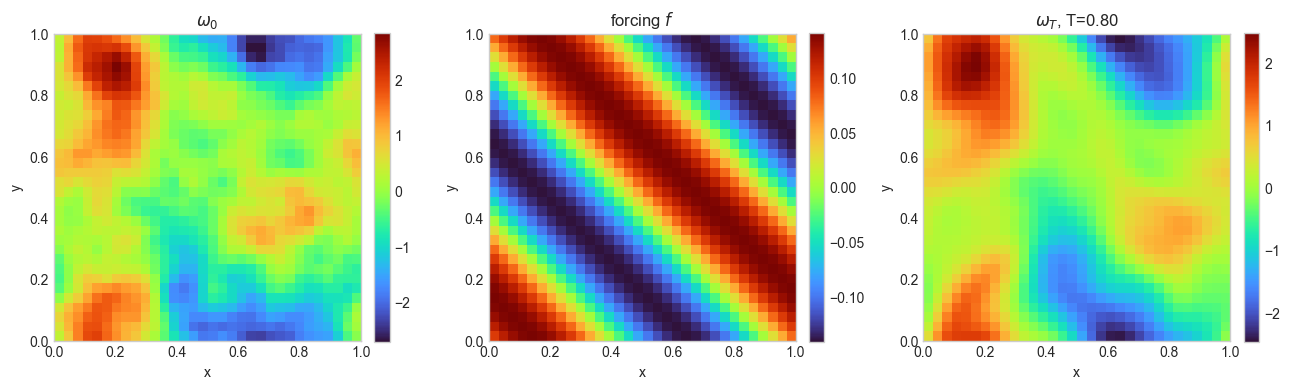

In [14]:
n = 32
nu = 1e-3
dt = 0.01
n_steps = 80
T = dt * n_steps

w0_demo = sample_initial_vorticity(n, rng)
wT_demo = solve_navier_stokes(w0_demo, nu=nu, dt=dt, n_steps=n_steps)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, field, title in zip(
    axes,
    [w0_demo, forcing_field(n), wT_demo],
    ['$\\omega_0$', 'forcing $f$', f'$\\omega_T$, T={T:.2f}'],
):
    im = ax.imshow(field.T, origin='lower', extent=[0, 1, 0, 1], cmap='turbo')
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()


## 2. Function-to-function training pairs

Each training example is a pair

$$
\omega_0(x,y) \longmapsto \omega_T(x,y).
$$

This is operator learning: a single model should work for many possible initial vorticity fields drawn from the same distribution. We use a tiny dataset by modern standards so that the notebook can run during class.


In [15]:
def build_dataset(n_samples, n, rng, nu=1e-3, dt=0.01, n_steps=80):
    inputs = np.empty((n_samples, n, n), dtype=np.float32)
    targets = np.empty((n_samples, n, n), dtype=np.float32)
    for i in range(n_samples):
        w0 = sample_initial_vorticity(n, rng)
        wT = solve_navier_stokes(w0, nu=nu, dt=dt, n_steps=n_steps)
        inputs[i] = w0
        targets[i] = wT
    return inputs, targets


n_train = 56
n_test = 16

w0_all, wT_all = build_dataset(n_train + n_test, n, rng, nu=nu, dt=dt, n_steps=n_steps)
w0_train, w0_test = w0_all[:n_train], w0_all[n_train:]
wT_train, wT_test = wT_all[:n_train], wT_all[n_train:]

# Scalar normalization keeps the model usable on grids with different sizes.
w_mean = w0_train.mean()
w_std = w0_train.std() + 1e-6

w0_train_n = (w0_train - w_mean) / w_std
w0_test_n = (w0_test - w_mean) / w_std
wT_train_n = (wT_train - w_mean) / w_std
wT_test_n = (wT_test - w_mean) / w_std

x_train = torch.tensor(w0_train_n[..., None], dtype=torch.float32)
y_train = torch.tensor(wT_train_n[..., None], dtype=torch.float32)
x_test = torch.tensor(w0_test_n[..., None], dtype=torch.float32, device=device)
y_test = torch.tensor(wT_test_n[..., None], dtype=torch.float32, device=device)

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=8, shuffle=True)
print(x_train.shape, y_train.shape)


torch.Size([56, 32, 32, 1]) torch.Size([56, 32, 32, 1])


## 3. The Fourier layer

A standard convolution learns local spatial filters. An FNO layer instead applies a learned linear transform to a small number of Fourier modes:

1. transform the field with an FFT,
2. keep only low-frequency modes,
3. multiply those complex modes by learned complex weights,
4. transform back to physical space.

The layer also includes a pointwise $1 \times 1$ convolution. That local channel mixing acts like the learned $Wv(x)$ term in the FNO update, while the spectral path acts like a global convolution kernel.


In [16]:
class SpectralConv2d(nn.Module):
    """2D Fourier layer that learns complex weights for low-frequency modes."""

    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat)
        )
        self.weights2 = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat)
        )

    @staticmethod
    def compl_mul2d(x, weights):
        return torch.einsum('bixy,ioxy->boxy', x, weights)

    def forward(self, x):
        batch_size, _, height, width = x.shape
        x_ft = torch.fft.rfft2(x)
        out_ft = torch.zeros(
            batch_size,
            self.out_channels,
            height,
            width // 2 + 1,
            dtype=torch.cfloat,
            device=x.device,
        )

        m1 = min(self.modes1, height)
        m2 = min(self.modes2, width // 2 + 1)
        out_ft[:, :, :m1, :m2] = self.compl_mul2d(x_ft[:, :, :m1, :m2], self.weights1[:, :, :m1, :m2])
        out_ft[:, :, -m1:, :m2] = self.compl_mul2d(x_ft[:, :, -m1:, :m2], self.weights2[:, :, :m1, :m2])
        return torch.fft.irfft2(out_ft, s=(height, width))


## 4. A compact 2D FNO

The input to the network is not only $\omega_0$. We also append normalized coordinate channels $(x,y)$ so the model knows where a value is located. The coordinates are periodic here, but including them matches the common FNO implementation pattern and makes the model easier to adapt to non-periodic examples later.


In [17]:
class FNO2d(nn.Module):
    def __init__(self, modes=10, width=24, depth=4):
        super().__init__()
        self.modes = modes
        self.width = width
        self.fc0 = nn.Linear(3, width)  # vorticity plus x and y coordinates
        self.spectral_layers = nn.ModuleList([
            SpectralConv2d(width, width, modes, modes) for _ in range(depth)
        ])
        self.pointwise_layers = nn.ModuleList([
            nn.Conv2d(width, width, kernel_size=1) for _ in range(depth)
        ])
        self.fc1 = nn.Linear(width, 64)
        self.fc2 = nn.Linear(64, 1)

    @staticmethod
    def grid(batch_size, height, width, device):
        x = torch.linspace(0, 1, height, device=device)
        y = torch.linspace(0, 1, width, device=device)
        xx, yy = torch.meshgrid(x, y, indexing='ij')
        grid = torch.stack((xx, yy), dim=-1)
        return grid.unsqueeze(0).repeat(batch_size, 1, 1, 1)

    def forward(self, x):
        batch_size, height, width, _ = x.shape
        coords = self.grid(batch_size, height, width, x.device)
        x = torch.cat((x, coords), dim=-1)
        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2)

        for spectral, pointwise in zip(self.spectral_layers, self.pointwise_layers):
            x = F.gelu(spectral(x) + pointwise(x))

        x = x.permute(0, 2, 3, 1)
        x = F.gelu(self.fc1(x))
        return self.fc2(x)


model = FNO2d(modes=10, width=24, depth=4).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {n_params:,}')


Model parameters: 464,961


## 5. Train the neural operator

The loss is mean squared error on the normalized vorticity field. For a research-grade workflow we would use more data, tune the architecture, and evaluate autoregressive rollouts. Here we keep the loop readable and short.


In [18]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

def relative_l2(pred, truth):
    pred_f = pred.reshape(pred.shape[0], -1)
    truth_f = truth.reshape(truth.shape[0], -1)
    return (torch.linalg.norm(pred_f - truth_f, dim=1) / torch.linalg.norm(truth_f, dim=1)).mean()


history = []
n_epochs = 35
for epoch in range(1, n_epochs + 1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = F.mse_loss(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.shape[0]
    scheduler.step()
    train_loss /= n_train

    model.eval()
    with torch.no_grad():
        test_pred = model(x_test)
        test_mse = F.mse_loss(test_pred, y_test).item()
        test_rel = relative_l2(test_pred, y_test).item()
    history.append((train_loss, test_mse, test_rel))

    if epoch == 1 or epoch % 5 == 0:
        print(f'epoch {epoch:02d} | train mse {train_loss:.4f} | test mse {test_mse:.4f} | test rel L2 {test_rel:.3f}')


epoch 01 | train mse 0.8003 | test mse 0.6329 | test rel L2 0.865
epoch 05 | train mse 0.0876 | test mse 0.1002 | test rel L2 0.343
epoch 10 | train mse 0.0233 | test mse 0.0352 | test rel L2 0.204
epoch 15 | train mse 0.0089 | test mse 0.0316 | test rel L2 0.193
epoch 20 | train mse 0.0037 | test mse 0.0292 | test rel L2 0.185
epoch 25 | train mse 0.0019 | test mse 0.0293 | test rel L2 0.185
epoch 30 | train mse 0.0009 | test mse 0.0291 | test rel L2 0.184
epoch 35 | train mse 0.0006 | test mse 0.0293 | test rel L2 0.185


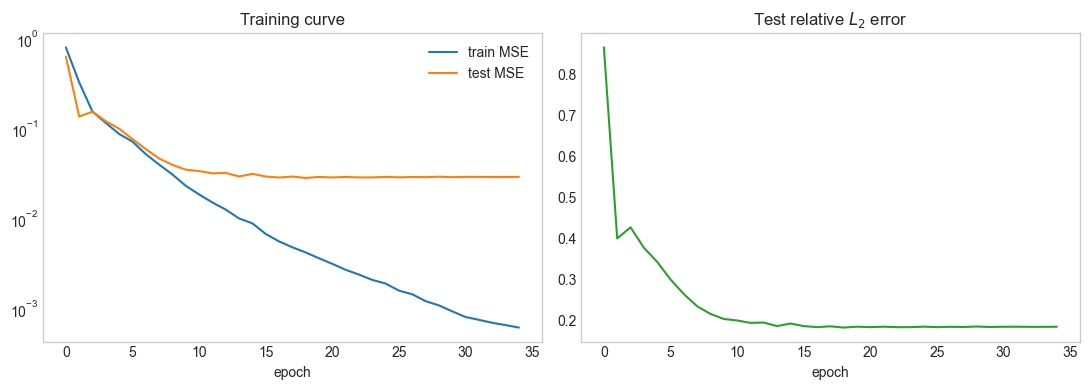

In [19]:
history = np.array(history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history[:, 0], label='train MSE')
axes[0].plot(history[:, 1], label='test MSE')
axes[0].set_yscale('log')
axes[0].set_xlabel('epoch')
axes[0].set_title('Training curve')
axes[0].legend()

axes[1].plot(history[:, 2], color='tab:green')
axes[1].set_xlabel('epoch')
axes[1].set_title('Test relative $L_2$ error')
plt.tight_layout()


## 6. Evaluate on unseen initial conditions

The model has learned an approximate solution operator. It is not memorizing one trajectory; it is predicting the later vorticity field for new initial conditions that were not used during training.


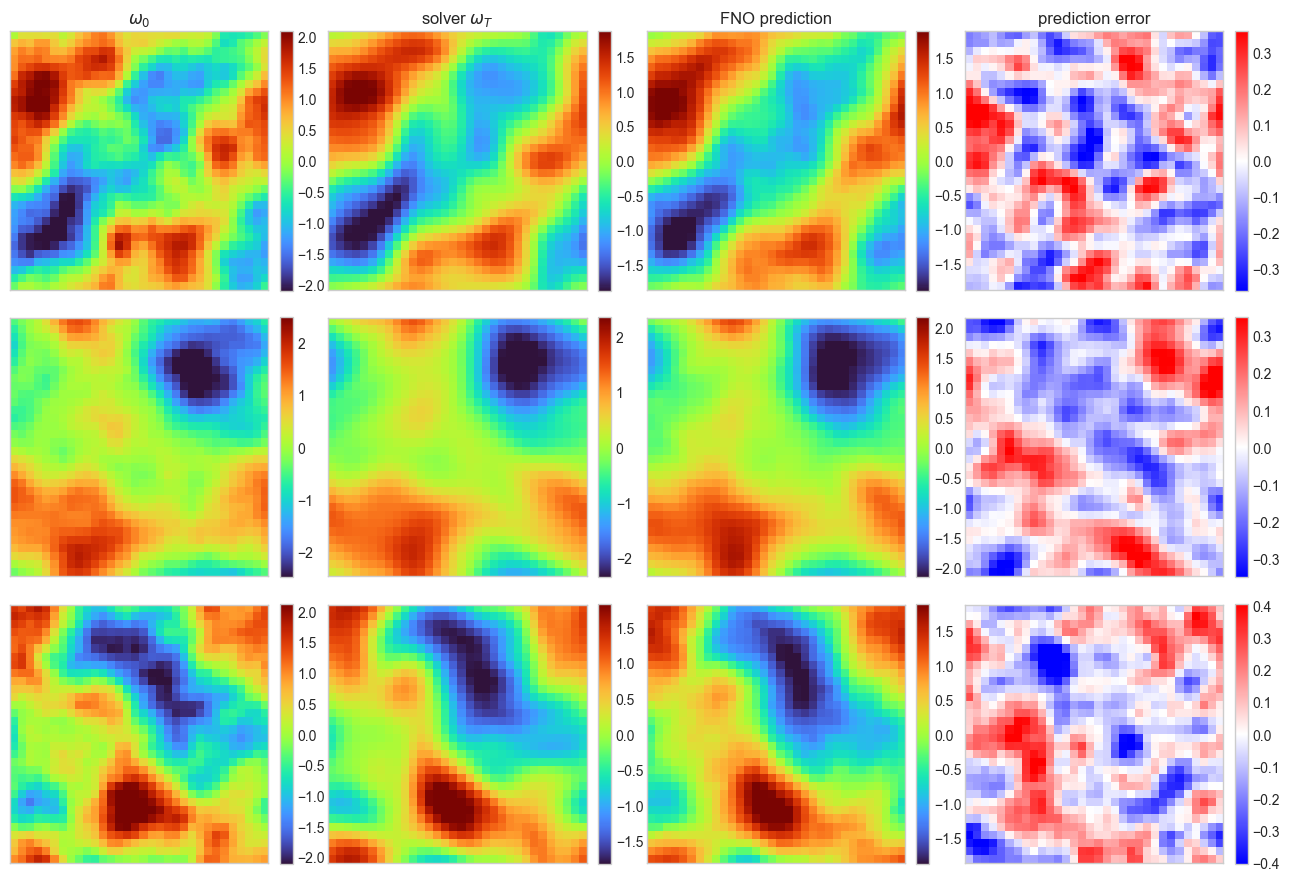

In [20]:
model.eval()
with torch.no_grad():
    pred_test_n = model(x_test).cpu().numpy()[..., 0]

pred_test = pred_test_n * w_std + w_mean
sample_ids = [0, 1, 2]
fig, axes = plt.subplots(len(sample_ids), 4, figsize=(13, 9))

for row, idx in enumerate(sample_ids):
    fields = [w0_test[idx], wT_test[idx], pred_test[idx], pred_test[idx] - wT_test[idx]]
    titles = ['$\\omega_0$', 'solver $\\omega_T$', 'FNO prediction', 'prediction error']
    cmaps = ['turbo', 'turbo', 'turbo', 'bwr']
    for col, (field, title, cmap) in enumerate(zip(fields, titles, cmaps)):
        ax = axes[row, col]
        vmax = np.percentile(np.abs(field), 98)
        im = ax.imshow(field.T, origin='lower', extent=[0, 1, 0, 1], vmin=-vmax, vmax=vmax, cmap=cmap)
        if row == 0:
            ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()


## 7. What did the Fourier layer keep?

The FNO only learns weights for a limited number of Fourier modes. That is a feature, not just a compression trick. For viscous flows on a coarse grid, much of the predictable structure is in the lower spatial frequencies, while the highest frequencies are more expensive and harder to learn from limited data.


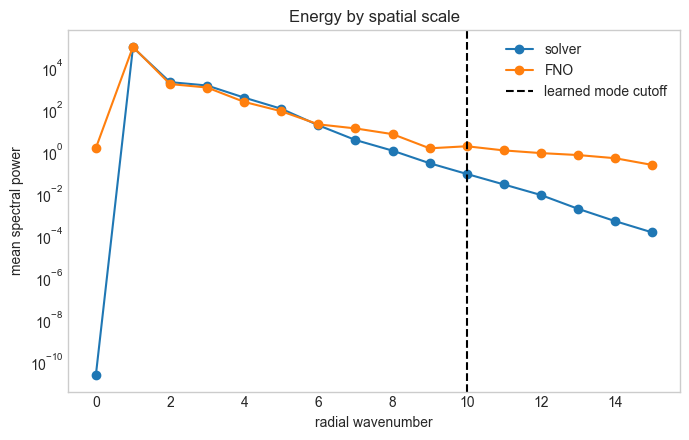

In [21]:
def radial_spectrum(field):
    n = field.shape[0]
    coeff = np.fft.fft2(field)
    power = np.abs(coeff)**2
    kx = np.fft.fftfreq(n) * n
    ky = np.fft.fftfreq(n) * n
    kkx, kky = np.meshgrid(kx, ky, indexing='ij')
    radius = np.sqrt(kkx**2 + kky**2).astype(int)
    max_r = n // 2
    spec = np.array([power[radius == r].mean() if np.any(radius == r) else np.nan for r in range(max_r)])
    return np.arange(max_r), spec

idx = 0
r, spec_true = radial_spectrum(wT_test[idx])
_, spec_pred = radial_spectrum(pred_test[idx])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(r, spec_true, 'o-', label='solver')
ax.semilogy(r, spec_pred, 'o-', label='FNO')
ax.axvline(model.modes, color='k', ls='--', lw=1.5, label='learned mode cutoff')
ax.set_xlabel('radial wavenumber')
ax.set_ylabel('mean spectral power')
ax.set_title('Energy by spatial scale')
ax.legend()
plt.tight_layout()


## 8. Zero-shot evaluation on a finer grid

One appeal of FNOs is that the learned spectral convolution is not tied as tightly to one fixed mesh size as a dense vector-to-vector model. Since our model applies FFTs and pointwise channel maps, we can feed it a different grid size without changing the weights.

This is a limited demonstration. The model was trained only on $32 \times 32$ fields, so fine-grid prediction is not guaranteed to be highly accurate. The point is that the architecture can be evaluated on a new discretization at all.


Fine-grid relative L2 error: 0.141


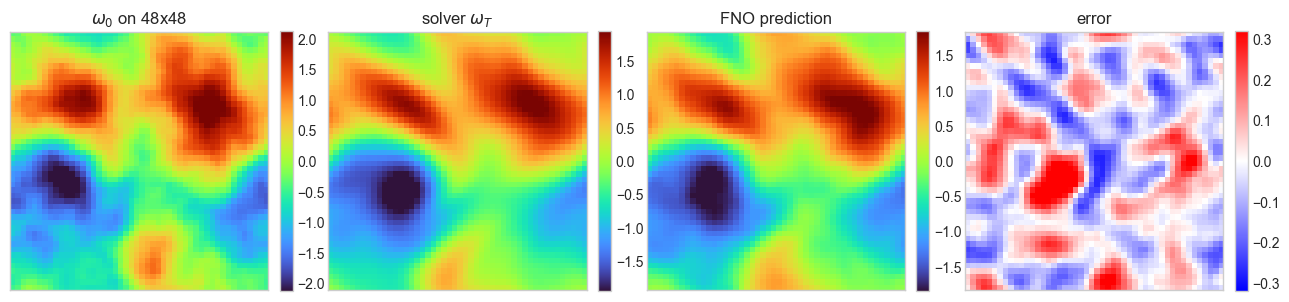

In [22]:
n_fine = 48
w0_fine = sample_initial_vorticity(n_fine, rng)
wT_fine = solve_navier_stokes(w0_fine, nu=nu, dt=dt, n_steps=n_steps)
w0_fine_n = (w0_fine - w_mean) / w_std

with torch.no_grad():
    x_fine = torch.tensor(w0_fine_n[None, ..., None], dtype=torch.float32, device=device)
    pred_fine_n = model(x_fine).cpu().numpy()[0, ..., 0]
pred_fine = pred_fine_n * w_std + w_mean

rel_fine = np.linalg.norm(pred_fine - wT_fine) / np.linalg.norm(wT_fine)
print(f'Fine-grid relative L2 error: {rel_fine:.3f}')

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
fields = [w0_fine, wT_fine, pred_fine, pred_fine - wT_fine]
titles = ['$\\omega_0$ on 48x48', 'solver $\\omega_T$', 'FNO prediction', 'error']
cmaps = ['turbo', 'turbo', 'turbo', 'bwr']
for ax, field, title, cmap in zip(axes, fields, titles, cmaps):
    vmax = np.percentile(np.abs(field), 98)
    im = ax.imshow(field.T, origin='lower', extent=[0, 1, 0, 1], vmin=-vmax, vmax=vmax, cmap=cmap)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()


## 9. Forecast error by lead time

The model above was trained for one lead time: $T = 0.8$. It is useful to ask what happens if we compare that same prediction to solver states at other forecast lead times.

This is not a multi-step rollout and not a model trained with time as an input. It is a diagnostic: the FNO has learned one operator, approximately

$$
\omega_0 \mapsto \omega_{0.8}.
$$

So we expect its error to be smallest near the lead time used for training. Away from that time, the prediction may still look physically plausible, but it is solving the wrong forecasting question.

lead time | FNO rel L2 | persistence rel L2
    0.20 |      0.306 |              0.160
    0.40 |      0.233 |              0.282
    0.60 |      0.189 |              0.381
    0.80 |      0.194 |              0.463
    1.00 |      0.238 |              0.532
    1.20 |      0.296 |              0.592


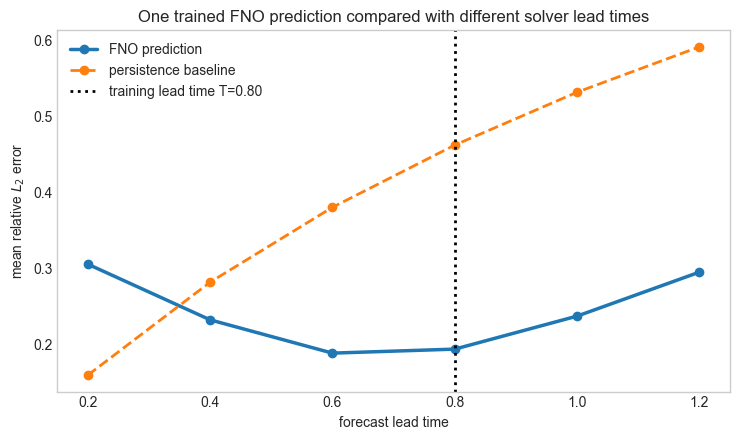

In [23]:

forecast_steps = np.array([20, 40, 60, 80, 100, 120])
forecast_times = forecast_steps * dt
n_forecast_samples = min(8, len(w0_test))

# The trained FNO produces one fixed lead-time prediction from each initial condition.
fno_forecast = pred_test[:n_forecast_samples]
persistence = w0_test[:n_forecast_samples]

fno_errors = []
persistence_errors = []
for steps in forecast_steps:
    truth = np.stack([
        solve_navier_stokes(w0_test[i], nu=nu, dt=dt, n_steps=int(steps))
        for i in range(n_forecast_samples)
    ])

    fno_rel = np.linalg.norm((fno_forecast - truth).reshape(n_forecast_samples, -1), axis=1) / np.linalg.norm(
        truth.reshape(n_forecast_samples, -1), axis=1
    )
    persistence_rel = np.linalg.norm((persistence - truth).reshape(n_forecast_samples, -1), axis=1) / np.linalg.norm(
        truth.reshape(n_forecast_samples, -1), axis=1
    )
    fno_errors.append(fno_rel.mean())
    persistence_errors.append(persistence_rel.mean())

print('lead time | FNO rel L2 | persistence rel L2')
for lead, fno_err, pers_err in zip(forecast_times, fno_errors, persistence_errors):
    print(f'{lead:8.2f} | {fno_err:10.3f} | {pers_err:18.3f}')

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(forecast_times, fno_errors, 'o-', lw=2.5, label='FNO prediction')
ax.plot(forecast_times, persistence_errors, 'o--', lw=2, label='persistence baseline')
ax.axvline(T, color='k', ls=':', lw=2, label=f'training lead time T={T:.2f}')
ax.set_xlabel('forecast lead time')
ax.set_ylabel('mean relative $L_2$ error')
ax.set_title('One trained FNO prediction compared with different solver lead times')
ax.legend()
plt.tight_layout()


## 10. Takeaways

- The original FNO Navier-Stokes benchmark learns solution operators for forced 2D incompressible flow in vorticity form on a periodic domain.
- This notebook keeps that same physical setting but reduces the data, grid size, prediction horizon, and model size.
- A Fourier layer is well matched to periodic PDEs because derivatives, smoothing, and long-range interactions are naturally expressed in spectral space.
- Neural operators learn maps between fields. Here that map is $\omega_0(x,y) \mapsto \omega_T(x,y)$.
- Resolution transfer is an architectural possibility, not a promise of accuracy. It needs adequate training data and validation.

Possible extensions:

1. Increase $T$ and compare one-step prediction to repeated rollout.
2. Train with different viscosities and include $\nu$ as an input parameter.
3. Compare the FNO to a small CNN with a similar parameter count.
4. Train on $32 \times 32$ and evaluate systematically on $48 \times 48$ or $64 \times 64$.
